In [2]:
import pandas as pd
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


In [4]:
transactions = pd.read_csv("../data/processed/feature_retail.csv")
customers = pd.read_csv("../data/processed/customer_features.csv")

In [5]:
transactions.head()

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country,order_value,invoice_year,invoice_month,invoice_hour
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,12,8
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,8
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,12,8
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,8
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,8


In [6]:
customers.head()

,customer_id,total_spend,total_items,avg_order_value,total_orders
0,12346.0,77183.60,74215,77183.600000,1
1,12347.0,4310.00,2458,23.681319,7
2,12348.0,1797.24,2341,57.975484,4
3,12349.0,1757.55,631,24.076027,1
4,12350.0,334.40,197,19.670588,1


In [7]:
transactions.shape

(397924, 12)

In [9]:
customers.shape

(4339, 5)

In [10]:
country_revenue = (
    transactions
    .groupby("country")["order_value"]
    .sum()
    .sort_values(ascending=False)
)

country_revenue.head(10)

country
United Kingdom    7308391.554
Netherlands        285446.340
EIRE               265545.900
Germany            228867.140
France             209024.050
Australia          138521.310
Spain               61577.110
Switzerland         56443.950
Belgium             41196.340
Sweden              38378.330
Name: order_value, dtype: float64

<function matplotlib.pyplot.show(close=None, block=None)>

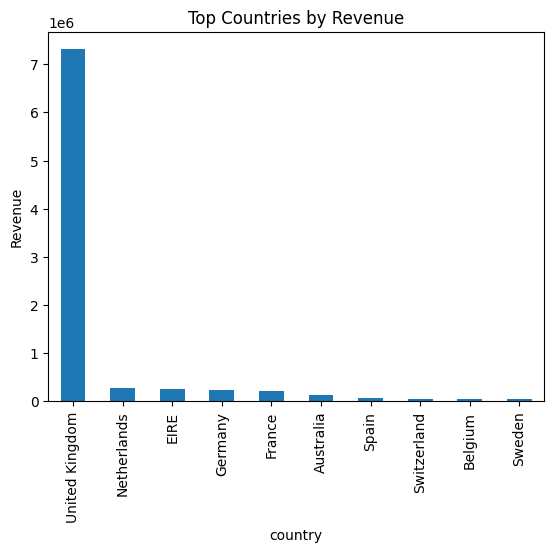

In [11]:
country_revenue.head(10).plot(kind="bar")

plt.title("Top Countries by Revenue")
plt.ylabel("Revenue")
plt.show

In [12]:
monthly_sales = (
    transactions
    .groupby("invoice_month")["order_value"]
    .sum()
)
monthly_sales

invoice_month
1      569445.040
2      447137.350
3      595500.760
4      469200.361
5      678594.560
6      661213.690
7      600091.011
8      645343.900
9      952838.382
10    1039318.790
11    1161817.380
12    1090906.680
Name: order_value, dtype: float64

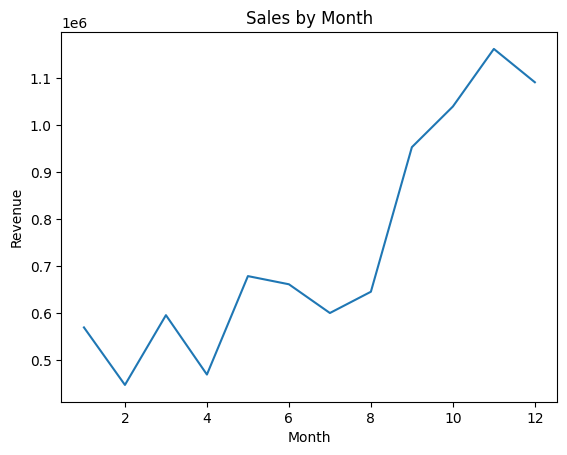

In [13]:
monthly_sales.plot()

plt.title("Sales by Month")
plt.ylabel("Revenue")
plt.xlabel("Month")
plt.show()

In [14]:
customers.sort_values("total_spend", ascending=False).head(10)

,customer_id,total_spend,total_items,avg_order_value,total_orders
1690,14646.0,280206.02,197491,134.714433,74
4202,18102.0,259657.30,64124,602.453132,60
3729,17450.0,194550.79,69993,577.302047,46
3009,16446.0,168472.50,80997,56157.500000,2
1880,14911.0,143825.06,80515,25.334694,201
55,12415.0,124914.53,77670,174.461634,21
1334,14156.0,117379.63,57885,83.842593,55
3772,17511.0,91062.38,64549,94.561142,31
2703,16029.0,81024.84,40208,334.813388,63
0,12346.0,77183.60,74215,77183.600000,1


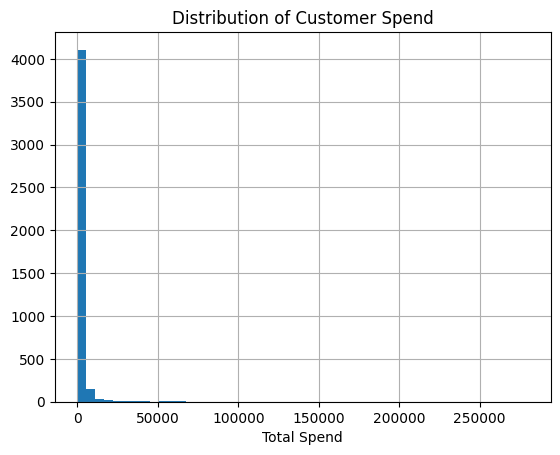

In [15]:
customers["total_spend"].hist(bins=50)

plt.title("Distribution of Customer Spend")
plt.xlabel("Total Spend")
plt.show()